In [13]:
import os
from dotenv import load_dotenv, find_dotenv
import sys
import asyncio

if sys.platform.startswith('win'):
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

_ = load_dotenv(find_dotenv())

In [14]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA, NVIDIAEmbeddings, NVIDIA
from langchain_openai import ChatOpenAI
from langchain_postgres.vectorstores import PGVector

CONNECTION = os.environ.get("PGVT_CONNECTION")
COLLECTION_NAME = "documents"
DOCUMENT_RELEVANT_THRESHOLD = 0.7
RETRY_RETRIEVAL_COUNT = 0

# llm = ChatOpenAI(
#     base_url="https://integrate.api.nvidia.com/v1",
#     model="meta/llama-3.3-70b-instruct",
#     streaming=True,
#     )

llm = ChatOpenAI(
    model="ft:gpt-4o-mini-2024-07-18:financial::AebWqcy2",
    streaming=True,
    )

# llm = ChatNVIDIA(
#     model="meta/llama-3.1-405b-instruct",
#     temperature=0.5,
# )

chat_model = ChatNVIDIA(
    model="meta/llama-3.1-70b-instruct",
    temperature=0.5,
)

embeddings = NVIDIAEmbeddings(
    model="nvidia/nv-embedqa-mistral-7b-v2",
    truncate="END"
)

vector_store = PGVector(
    embeddings=embeddings,
    collection_name=COLLECTION_NAME,
    connection=CONNECTION,
    use_jsonb=True,
)

In [15]:
### Search
import yfinance as yf
import pandas as pd
import numpy as np
import json
import uuid
from typing import List
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from datetime import datetime, timedelta
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnableConfig
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import BaseOutputParser
from langchain.tools.retriever import create_retriever_tool


def get_user_id(config: RunnableConfig) -> str:
    user_id = config["configurable"].get("user_id", "")
    if user_id is None:
        raise ValueError("User ID needs to be provided to save a memory.")

    return user_id

web_search_tool = TavilySearchResults(name="web_search", k=3)


class LineListOutputParser(BaseOutputParser[List[str]]):
    """Output parser for a list of lines."""

    def parse(self, text: str) -> List[str]:
        lines = text.strip().split("\n")
        return list(filter(None, lines))  # Remove empty lines
    
class RetrieverInput(BaseModel):
    """Input to the retriever."""

    query: str = Field(description="query to look up in retriever")

@tool(args_schema=RetrieverInput)
def retrieve(query: str, config: RunnableConfig):
    """A retrieval tool optimized for extracting relevant financial information 
    from user-uploaded documents, which may be extensive and complex. 
    It identifies key insights efficiently, focusing on topics 
    like market analysis, economic trends, and investment strategies,
    to assist the agent in generating accurate, 
    domain-specific responses without unnecessary delays"""

    user_id = get_user_id(config)
    filter = {"user_id": {"$eq": user_id}}
    search_kwargs = {
        "k": 3,
        "fetch_k": 5,
        # "filter": filter
    }
    retriever = vector_store.as_retriever(search_type="mmr",
                                          search_kwargs=search_kwargs)
    retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_docs",
    "A retrieval tool optimized for extracting relevant financial information from user-uploaded documents, which may be extensive and complex. It identifies key insights efficiently, focusing on topics like market analysis, economic trends, and investment strategies, to assist the agent in generating accurate, domain-specific responses without unnecessary delays",)
    docs = retriever_tool.invoke(query)

    return docs


class FinancialDataSchema(BaseModel):
    ticker: str = Field(..., description="The stock ticker symbol for which financial data is being retrieved. Ex: APPL, NVDA,...", )

@tool(args_schema=FinancialDataSchema)
def get_financial_data(ticker: str) -> str:
    """A comprehensive tool designed to fetch detailed 
    financial information for a given stock ticker, 
    serving as a critical component in financial analysis and investment research. 
    Capabilities: 
    Retrieves real-time and historical financial data, 
    Provides in-depth financial metrics and insights,
    Designed for use in automated financial agents and analysis systems"""
    current_date = datetime.today()
    target_date = datetime.today() - timedelta(weeks=1)
    stock = yf.Ticker(ticker)
    df = stock.history(start=target_date, end=current_date, interval='1d', raise_errors=True)
    df['Trend'] = np.where(df['Close'].shift(-1) > df['Close'], "Up", "Down")
    result = df.sort_values(by=[df.index.name], ascending=False).to_dict('records')[0]
    json_output = json.dumps(result)

    return f"Here the realtime information about {ticker} stock: \n {json_output}"

class SaveRecallMemory(BaseModel):
    memory: str = Field(..., description="A string containing information from the user, such as facts, experiences, or instructions, which will be analyzed and saved as a memory")

@tool(args_schema=SaveRecallMemory)
def save_recall_memory(memory: str, config: RunnableConfig) -> str:
    """This function is designed to capture and save user-related memories. 
    It should be called when the user's query provides new information about their facts,
    experiences, or specific instructions. Saving these memories enables the chat model 
    to offer personalized and context-aware responses in future interactions"""
    user_id = get_user_id(config)
    document = [Document(
        page_content=memory, id=str(uuid.uuid4()), metadata={"user_id": user_id}
    )]
    vector_store.add_documents(document)

    return f"Memory: \"{memory}\" have been saved into vector store"

class SearchRecallMemory(BaseModel):
    query: str =  Field(..., description="A string representing the search input, which may include references to user-provided facts, experiences, or instructions")

@tool(args_schema=SearchRecallMemory)
def search_recall_memories(query: str, config: RunnableConfig) -> str:
    """searches for related memories based on a given query.
    It specifically identifies and retrieves user-related facts, experiences, 
    or instructions that are relevant to the query. The purpose is to 
    enhance contextual understanding and 
    provide more personalized or context-aware responses"""
    user_id = get_user_id(config)
    filter = {"user_id": {"$eq": user_id}}
    search_kwargs = {
        "k": 3,
        "fetch_k": 5,
        # "filter": filter
    }

    documents = vector_store.as_retriever(search_type="mmr",
                                                 search_kwargs=search_kwargs).invoke(query)
    content = "\n".join(document.page_content for document in documents)
    return f"Recall memories context: {content}"


tools = [web_search_tool, retrieve, get_financial_data, save_recall_memory, search_recall_memories]


In [16]:
from langgraph.graph import END, START, MessagesState, StateGraph
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Sequence

class AgentState(TypedDict):
    # add memories that will be retrieved based on the conversation context
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [17]:
agent_prompt = """You are a financial domain expert and a sophisticated assistant designed to aid users in making informed decisions about their next steps, whether or not specific context about a ticker, stock, or financial question is provided. You have access to the following tools:

{tools}

# Steps

1. Carefully review any context provided by the user about the ticker, stock, or financial question in question.
2. If context is not given, clarify and extract essential details needed for informed responses.
3. Utilize your available tools and current data to formulate accurate, reliable, and helpful responses.
4. Confirm the accuracy of the information before providing guidance.
5. If uncertain about the answer, clearly communicate that you don't know, rather than speculating.

# Instructions

Use the following format to structure your responses:

Question: The input question you must answer.
Thought: Analyze the question, consider the context or lack thereof, and decide your next steps.
Action: If needed, use one of the tools provided to obtain further information. The action must be one of [{tool_names}].
Action Input: The input you provide to the selected tool.
Observation: The result of the action.
... (This Thought/Action/Action Input/Observation process can repeat N times)
Thought: Conclude your analysis and formulate the final answer.
Final Answer: Provide a concise, well-reasoned answer to the original question.

# Output Guidelines

- Deliver clear, concise answers or suggestions in a professional tone.
- Emphasize the importance of making decisions based on verified information.
- Encourage further research or consultation with financial professionals when necessary.
- If insufficient information is available, politely seek clarification or communicate the limitations of your response.

# Examples

**Input:** "What do you think about investing in [Ticker XYZ] given the current market trends?"
**Question:** What do you think about investing in [Ticker XYZ] given the current market trends?
**Thought:** I should analyze the market trends for [Ticker XYZ], consider economic indicators, recent news, and company performance.
**Action:** Use [Tool Name]
**Action Input:** Query recent performance and news for [Ticker XYZ].
**Observation:** The tool returns data indicating strong recent performance in [specific sector].
**Thought:** I now know the final answer.
**Final Answer:** "Given the current market trends, [Ticker XYZ] shows potential due to its recent performance in [specific sector], but please consider the risks associated with [economic factor] before investing."

**Input:** "Is [Stock ABC] a good buy now?"
**Question:** Is [Stock ABC] a good buy now?
**Thought:** I should evaluate [Stock ABC]'s valuation metrics, recent financial earnings reports, and industry outlook.
**Action:** Use [Tool Name]
**Action Input:** Query valuation metrics and recent earnings for [Stock ABC].
**Observation:** The tool returns data indicating [specific valuation metric].
**Thought:** I now know the final answer.
**Final Answer:** "Based on its current valuation and industry outlook, [Stock ABC] might benefit from [current economic trend]. However, please review [financial report] for deeper insights."

# Notes

- Always think critically and ensure your analysis is based on verified information.
- Avoid making up information if data or context is insufficient.
- If clarification is needed, ask the user for additional details.
- Clearly communicate your reasoning and process at every step.

Begin!
"""
messages_prompt = ChatPromptTemplate.from_messages(
    [("system", agent_prompt), ("placeholder", "{messages}")]
  )

In [18]:
# Nodes
from langchain_core.messages import RemoveMessage

def agent(state: AgentState) -> AgentState:
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    tool_list = "\n\n".join([f"{idx + 1}. {tl.name}: {tl.description}" for idx, tl in enumerate(tools)])
    tool_names = ", ".join([tl.name for tl in tools])
    
    model = llm.bind_tools(tools)
    agent_chain = messages_prompt | model
    response = agent_chain.invoke({
        "tools": tool_list,
        "tool_names": tool_names,
        "messages": state["messages"]
    })
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


def delete_messages(state: AgentState) -> AgentState:
    messages = state["messages"]
    if len(messages) > 12:
        return {"messages": [RemoveMessage(msg.id) for msg in messages[:-12]]}

    return {"messages": messages}

In [19]:
from langgraph.prebuilt import ToolNode, tools_condition

# Create the graph and add nodes
workflow = StateGraph(AgentState)
workflow.add_node("agent", agent)  
workflow.add_node("delete_messages", delete_messages)  
workflow.add_node("tools", ToolNode(tools=tools))

# Add edges to the graph
workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "tools",
        END: "delete_messages",
    },
)
workflow.add_edge("tools", "agent")
workflow.add_edge("delete_messages", END)

In [20]:
from langchain_core.messages import AIMessageChunk

async def pretty_print_stream_chunk(msg, metadata):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end="", flush=True)
        if msg.response_metadata.get("finish_reason", "") == "stop":
            print("\n")
    else:
        print(msg.content)
        print("\n")

In [21]:
from psycopg import AsyncConnection
from langgraph.checkpoint.postgres.aio import AsyncPostgresSaver

DB_URI = os.environ.get("PSQL_CONNECTION")
connection_kwargs = {
    "autocommit": True,
    "prepare_threshold": 0,
}

conn = await AsyncConnection.connect(DB_URI, **connection_kwargs)
checkpointer = AsyncPostgresSaver(conn)
await checkpointer.setup()
graph = workflow.compile(checkpointer=checkpointer)

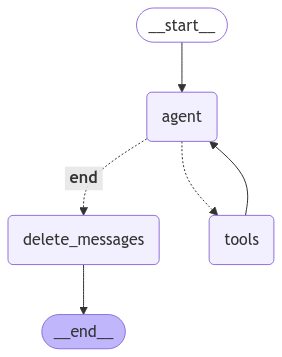

In [22]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [26]:
from langchain_core.messages import HumanMessage

config = {"configurable": {
    "user_id": "6746dd846f6d7f728d6cfba7", "thread_id": "chat_thread_2"}}

while True:
    query = input("Enter messages: ")
    if query == 'stop':
        break
    async for msg, metadata in graph.astream({"messages": [HumanMessage(query)]}, config=config, stream_mode="messages"):
        await pretty_print_stream_chunk(msg, metadata)

In my financial report. Tell me the most of money was spent on what category


In your financial report for November 2024, the most money was spent on the following categories:

1. **Housing**:
   - Rent: $1,200.00
   - Utilities: $150.00
   - Total: $1,350.00

This indicates that housing expenses were the highest among all categories in your financial report.







